In [45]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn as nn
from typing import *
from sklearn.svm import SVC


In [46]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [47]:
class BinaryHypercubeDataset(Dataset):
    def __init__(self, num_samples, N_dims=2, random_segment_ratios=False, spacing=2, noise_level=2):
        super(BinaryHypercubeDataset, self).__init__()

        self.__make_dataset__(num_samples, N_dims, random_segment_ratios, spacing, noise_level)

    def __flip_every_other_set__(self, array):
        # Ensure the array is a NumPy array
        array = np.array(array)

        # Reshape the array to separate pairs for easy manipulation
        pairs = array.reshape(-1, 2)

        # Flip every other pair
        pairs[1::2] = pairs[1::2, ::-1]

        # Reshape back to the original shape
        flipped_array = pairs.reshape(-1)
        return flipped_array

    def __make_dataset__(self, num_samples, N_dims, random_segment_ratios, spacing, noise_level):
        if random_segment_ratios:
            splits = np.random.dirichlet(np.ones(2**N_dims), size=1) * num_samples
            splits = list(splits)
        else:
            splits = [num_samples//(2**N_dims) for _ in range(2**N_dims)]

        splits = [0] + splits
        splits = np.cumsum(splits)
        corners_str = [bin(i)[2:].zfill(N_dims) for i in range(2**N_dims)]
        corners_list = np.array([[int(i) for i in c] for c in corners_str])
        corners_list *= spacing

        label_sets = [i%2 for i in range(2**N_dims)]
        label_sets = np.array(label_sets)
        label_sets = self.__flip_every_other_set__(label_sets)

        self.hf_dataset = np.zeros((num_samples, N_dims))
        self.lf_dataset = np.zeros((num_samples, N_dims))
        self.labels = np.zeros(num_samples)

        for s in range(1, len(splits)):
            # print(splits[s-1],splits[s])
            self.hf_dataset[splits[s-1]:splits[s]] = np.random.multivariate_normal(corners_list[s-1], np.zeros((N_dims,N_dims)), size=(splits[s]-splits[s-1]))
            # print(s-1)
            self.labels[splits[s-1]:splits[s]] = label_sets[s-1]

        self.lf_dataset = self.hf_dataset + np.random.standard_normal(size=(len(self.hf_dataset), N_dims)) * noise_level
        self.hf_dataset += np.random.standard_normal(size=(len(self.hf_dataset), N_dims)) * .4

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx:int):
        return self.lf_dataset[idx], self.hf_dataset[idx], self.labels[idx]

In [48]:
ds = BinaryHypercubeDataset(4000, N_dims=2, noise_level=.0)

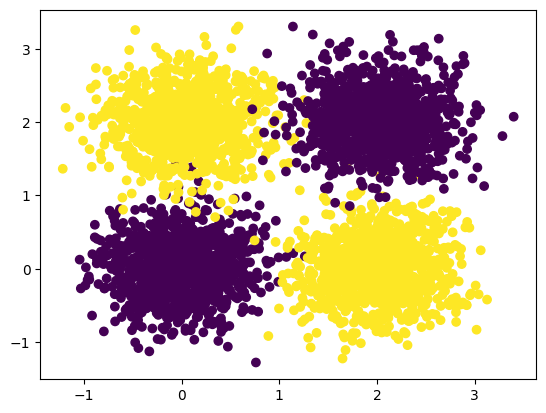

In [13]:
plt.scatter(ds.hf_dataset[:,0], ds.hf_dataset[:,1], c=ds.labels)

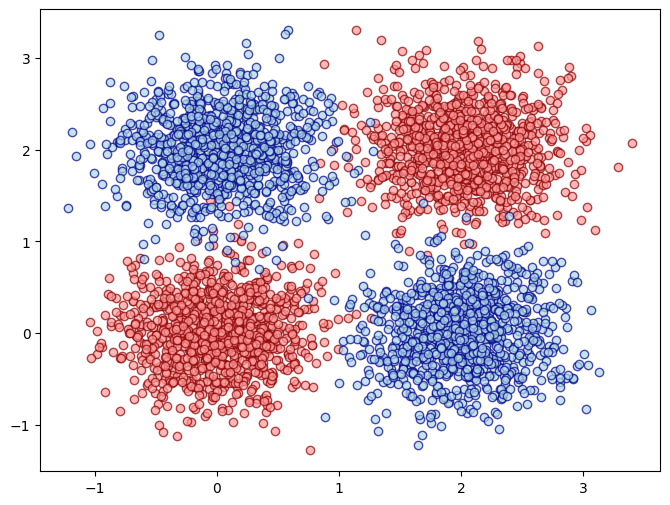

In [14]:
colors = np.array(['#FF9999', '#ADD8E6'])
edge_colors = np.array(['#8B0000', '#00008B'])

plt.figure(figsize=(8, 6))
for label in np.unique(ds.labels):
    label = int(label)
    plt.scatter(
        ds.hf_dataset[ds.labels == label, 0],
        ds.hf_dataset[ds.labels == label, 1],
        c=colors[label],
        edgecolors=edge_colors[label],
        alpha=0.7,
        label=f'Label {label}'
    )


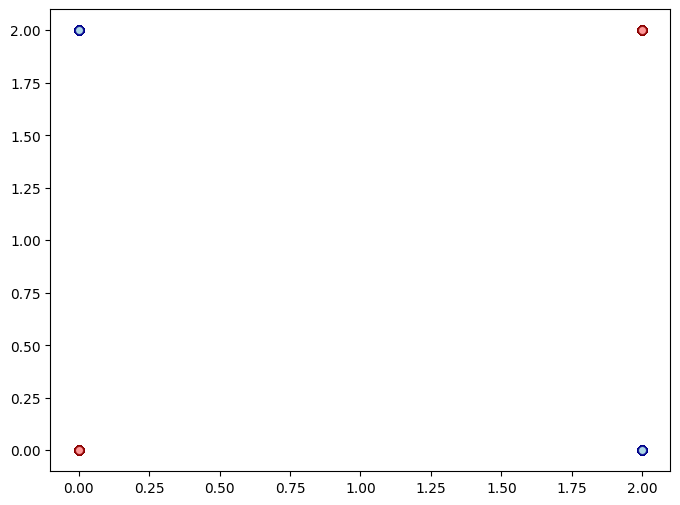

In [15]:
colors = np.array(['#FF9999', '#ADD8E6'])
edge_colors = np.array(['#8B0000', '#00008B'])

plt.figure(figsize=(8, 6))
for label in np.unique(ds.labels):
    label = int(label)
    plt.scatter(
        ds.lf_dataset[ds.labels == label, 0],
        ds.lf_dataset[ds.labels == label, 1],
        c=colors[label],
        edgecolors=edge_colors[label],
        alpha=0.7,
        label=f'Label {label}'
    )

In [16]:
def build_dataloaders(full_dataset, noise=1):
    # train_dataset = BinaryHypercubeDataset(1275, noise_level=noise)
    # test_dataset = BinaryHypercubeDataset(150, noise_level=noise)
    # val_dataset = BinaryHypercubeDataset(75, noise_level=noise)

    rand_idxs = np.random.choice(3, p=[.85, .1, .05], size=len(full_dataset))
    idxs = np.arange(len(full_dataset))

    train_dataset = Subset(full_dataset, idxs[rand_idxs==0])

    test_dataset = Subset(full_dataset, idxs[rand_idxs==1])
    val_dataset = Subset(full_dataset, idxs[rand_idxs==2])

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=True)

    return train_loader, test_loader, val_loader

In [73]:
x,y,z = build_dataloaders(ds)

x.batch_size

512

In [17]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [18]:
class QE_Dataset(Dataset):
    def __init__(self, lf_embeddings, lf_preds, hf_preds, labels):
        super(QE_Dataset, self).__init__()

        self.lf_embeddings = lf_embeddings
        self.lf_preds = lf_preds
        self.hf_preds = hf_preds
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx:int):
        return self.lf_embeddings[idx], self.lf_preds[idx], self.hf_preds[idx], self.labels[idx]

In [19]:
def build_qe_dataloaders(lf_model, hf_model, train_loader, test_loader, val_loader):
    lf_body = create_feature_extractor(
        lf_model, {"7": "body"}
    ).to(device)

    lf_body.eval()
    lf_model.eval()
    hf_model.eval()

    train_len = len(train_loader.dataset)
    test_len = len(test_loader.dataset)
    val_len = len(val_loader.dataset)

    batch_size = train_loader.batch_size
    
    train_qe_labels = np.zeros(train_len)
    test_qe_labels = np.zeros(test_len)
    val_qe_labels = np.zeros(val_len)

    train_lf_embeddings = np.zeros((train_len, 32))
    test_lf_embeddings = np.zeros((test_len, 32))
    val_lf_embeddings = np.zeros((val_len, 32))

    train_hf_preds = np.zeros((train_len, 2))
    test_hf_preds = np.zeros((test_len, 2))
    val_hf_preds = np.zeros((val_len, 2))

    train_lf_preds = np.zeros((train_len, 2))
    test_lf_preds = np.zeros((test_len, 2))
    val_lf_preds = np.zeros((val_len, 2))


    print("Building Train Dataset...")
    for i, (lf_data, hf_data, target) in enumerate(train_loader):
        target = target.type(torch.LongTensor)
        lf_data, hf_data, target = lf_data.to(device, torch.float), hf_data.to(device, torch.float), target.to(device)

        lf_preds = lf_model(lf_data)
        hf_preds = hf_model(hf_data)
        lf_embeddings = lf_body(lf_data)["body"]

        train_qe_labels[
            (i*batch_size):(i*batch_size+len(target))
        ] = target.detach().cpu().numpy()

        train_lf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_preds.detach().cpu().numpy()

        train_hf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = hf_preds.detach().cpu().numpy()

        train_lf_embeddings[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_embeddings.detach().cpu().numpy()

    train_dataset = QE_Dataset(train_lf_embeddings, train_lf_preds, train_hf_preds, train_qe_labels)

    print("Building Test Dataset...")
    for i, (lf_data, hf_data, target) in enumerate(test_loader):
        target = target.type(torch.LongTensor)
        lf_data, hf_data, target = lf_data.to(device, torch.float), hf_data.to(device, torch.float), target.to(device)

        lf_preds = lf_model(lf_data)
        hf_preds = hf_model(hf_data)
        lf_embeddings = lf_body(lf_data)["body"]

        test_qe_labels[
            (i*batch_size):(i*batch_size+len(target))
        ] = target.detach().cpu().numpy()

        test_lf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_preds.detach().cpu().numpy()

        test_hf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = hf_preds.detach().cpu().numpy()

        test_lf_embeddings[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_embeddings.detach().cpu().numpy()

    test_dataset = QE_Dataset(test_lf_embeddings, test_lf_preds, test_hf_preds, test_qe_labels)

    print("Building Validation Dataset...")
    for i, (lf_data, hf_data, target) in enumerate(val_loader):
        target = target.type(torch.LongTensor)
        lf_data, hf_data, target = lf_data.to(device, torch.float), hf_data.to(device, torch.float), target.to(device)

        lf_preds = lf_model(lf_data)
        hf_preds = hf_model(hf_data)
        lf_embeddings = lf_body(lf_data)["body"]

        val_qe_labels[
            (i*batch_size):(i*batch_size+len(target))
        ] = target.detach().cpu().numpy()

        val_lf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_preds.detach().cpu().numpy()

        val_hf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = hf_preds.detach().cpu().numpy()

        val_lf_embeddings[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_embeddings.detach().cpu().numpy()

    val_dataset = QE_Dataset(val_lf_embeddings, val_lf_preds, val_hf_preds, val_qe_labels)

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=512)
    val_loader = DataLoader(val_dataset, batch_size=512)

    return train_loader, test_loader, val_loader


In [20]:
class MetaLossFunction(nn.Module):
    def __init__(self, ch: List[float], cw: float, loss_fun: str="CE"):
        '''
        Loss function for the FE model
        Parameters:
            ch - cost of using high fidelity
            cw - cost of being wrong
            loss_fun - the choice of loss function used to determine wrong predictions
        '''
        super().__init__()
        self.ch = ch
        self.ch.insert(0, 0) # first element is zero because no cost for LF sample usage

        self.cw = cw

        match loss_fun:
            case "CE":
                self.loss_fun = nn.CrossEntropyLoss(reduction="none")
            case "binary":
                self.loss_fun = nn.L1Loss(reduction="none")
            case default:
                raise ValueError("Invalid loss function")

    def forward(self, y_true: torch.tensor, y_preds: torch.tensor, choices: torch.tensor):
        batch_size = len(y_true)
        model_losses = []

        with torch.no_grad():
            for pred in y_preds:
                loss = self.loss_fun(pred, y_true)
                model_losses.append(loss)

        model_losses_tensor = torch.stack(model_losses)

        cw_matrix = self.cw * torch.ones_like(model_losses_tensor)

        ch_matrix = torch.tensor(self.ch)
        ch_matrix = ch_matrix.view(-1, len(self.ch))
        ch_matrix = ch_matrix.repeat(batch_size, 1).T

        cw_matrix = cw_matrix.to(device)
        ch_matrix = ch_matrix.to(device)

        model_loss_weights = model_losses_tensor * (cw_matrix + ch_matrix)

        self.meta_loss = choices.T * model_loss_weights

        return torch.sum(self.meta_loss)

In [21]:
def one_run(model, dataloader, criterion, fidelity, optimizer=None, scheduler=None):
    """
    Perform one run through the DataLoader.

    Args:
    - model (torch.nn.Module): The neural network model.
    - dataloader (DataLoader): The DataLoader for iterating over the dataset.
    - criterion (callable): The loss function.
    - optimizer (torch.optim.Optimizer, optional): The optimizer for updating model weights.

    Returns:
    - float: Average loss over the run.
    - int: Correct predictions for calculating accuracy if needed.
    """
    if fidelity not in ["lf", "hf", "gate"]:
        return

    model.train(mode=bool(optimizer))
    device = next(model.parameters()).device
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_high = 0
    if fidelity == "lf":
        for data, _, target in dataloader:
            target = target.type(torch.LongTensor)
            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "hf":
        for _, data, target in dataloader:
            target = target.type(torch.LongTensor)
            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "gate":
        for lf_embeddings, lf_preds, hf_preds, target in dataloader:
            lf_embeddings = lf_embeddings.to(device, torch.float)
            lf_preds = lf_preds.to(device, torch.float)
            hf_preds = hf_preds.to(device, torch.float)

            target = target.type(torch.LongTensor)
            target = target.to(device)

            outputs = model(lf_embeddings)
            preds = torch.stack([
                lf_preds,
                hf_preds
            ])

            loss = criterion(target, preds, outputs)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            choices = torch.argmax(outputs, dim=1)
            lf_acc = torch.argmax(lf_preds, dim=1) == target
            hf_acc = torch.argmax(hf_preds, dim=1) == target

            total_loss += loss.item() * lf_preds.size(0)
            total_correct += torch.sum(hf_acc[choices==1]) + torch.sum(lf_acc[choices==0]).item()
            total_samples += lf_preds.size(0)
            total_high += torch.sum(choices).item()
        if scheduler:
            scheduler.step()

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    if fidelity=="gate":
        high_count = total_high / total_samples
        return average_loss, accuracy.item(), high_count

    return average_loss, accuracy

In [22]:
def build_qe_model(num_classes: int=2):
    qe_model = nn.Sequential(
        nn.Linear(32, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, num_classes),
        nn.Softmax(dim=1)
    )

    return qe_model

In [44]:
R_VALS = np.linspace(0.01, 3, 200)
NUM_RERUNS = 1
NUM_FIDELITY_EPOCHS = 50
NUM_QE_EPOCHS = 200

In [43]:
qe_train_acc = np.zeros((NUM_RERUNS, len(R_VALS)))
qe_train_use = np.zeros((NUM_RERUNS, len(R_VALS)))

qe_test_acc = np.zeros((NUM_RERUNS, len(R_VALS)))
qe_test_use = np.zeros((NUM_RERUNS, len(R_VALS)))

qe_val_acc = np.zeros((NUM_RERUNS, len(R_VALS)))
qe_val_use = np.zeros((NUM_RERUNS, len(R_VALS)))

full_dataset = BinaryHypercubeDataset(4000, noise_level=1.1)

for run_num in range(NUM_RERUNS):
    lf_model = torch.nn.Sequential(
        torch.nn.Linear(2, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 128),
        torch.nn.ReLU(),
        torch.nn.Linear(128, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 2)
    ).to(device)

    lf_optimizer = torch.optim.Adam(lf_model.parameters(), lr=3e-3, weight_decay=1e-5)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ExponentialLR(lf_optimizer, gamma=0.99)
    early_stopper = EarlyStopper(patience=5)

    train_loader, test_loader, val_loader = build_dataloaders(full_dataset)


    for epoch in range(NUM_FIDELITY_EPOCHS):
        train_loss, train_acc = one_run(lf_model, train_loader, criterion, fidelity="lf", optimizer=lf_optimizer, scheduler=scheduler)
        test_loss, test_acc = one_run(lf_model, test_loader, criterion, fidelity="lf", optimizer=lf_optimizer, scheduler=scheduler)
        val_loss, val_acc = one_run(lf_model, val_loader, criterion, fidelity="lf", optimizer=lf_optimizer, scheduler=scheduler)

        print(train_acc, val_acc)
        if early_stopper.early_stop(val_loss):
            break
        # scheduler.step(

    print("\n\n\n")

    hf_model = torch.nn.Sequential(
        torch.nn.Linear(2, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 128),
        torch.nn.ReLU(),
        torch.nn.Linear(128, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 2)
    ).to(device)

    hf_optimizer = torch.optim.Adam(hf_model.parameters(), lr=3e-3, weight_decay=1e-5)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ExponentialLR(hf_optimizer, gamma=0.99)
    early_stopper = EarlyStopper(patience=5)

    for epoch in range(NUM_FIDELITY_EPOCHS):
        train_loss, train_acc = one_run(hf_model, train_loader, criterion, fidelity="hf", optimizer=hf_optimizer, scheduler=scheduler)
        test_loss, test_acc = one_run(hf_model, test_loader, criterion, fidelity="hf", optimizer=hf_optimizer, scheduler=scheduler)
        val_loss, val_acc = one_run(hf_model, val_loader, criterion, fidelity="hf", optimizer=hf_optimizer, scheduler=scheduler)

        print(train_acc, val_acc)
        if early_stopper.early_stop(val_loss):
            break

    
    qe_train_loader, qe_test_loader, qe_val_loader = build_qe_dataloaders(lf_model, hf_model, train_loader, test_loader, val_loader)

    dataloaders = {
        "train": qe_train_loader,
        "test": qe_test_loader,
        "val": qe_val_loader
    }

    test_positions = qe_test_loader.inputs

    svm_model = None
    for r, r_val in enumerate(R_VALS):
        print(f"r: {r_val} ({round((r+1)/len(R_VALS)*100, 2)}%)")
        for loader_name in dataloaders.keys():
            loader = dataloaders[loader_name]

            lf_embeds = loader.dataset.lf_embeddings
            lf_preds = loader.dataset.lf_preds
            hf_preds = loader.dataset.hf_preds
            labels = loader.dataset.labels

            lf_correct = np.argmax(lf_preds, axis=1) == labels
            hf_correct = np.argmax(hf_preds, axis=1) == labels

            best_choices = np.logical_and(~lf_correct, hf_correct).astype(int)
        
            if loader_name == "train":
                weights = np.where(best_choices==1, r_val, 1)
                svm_model = SVC(kernel="rbf", class_weight="balanced")
                svm_model.fit(lf_embeds, best_choices, sample_weight=weights)

            outputs = svm_model.predict(lf_embeds)
            acc = np.sum(lf_correct[outputs==0]) + np.sum(hf_correct[outputs==1]) / len(outputs)
            usage = np.sum(outputs) / len(outputs)

            if loader_name == "train":
                qe_train_acc[run_num, r] = acc
                qe_train_use[run_num, r] = usage

            elif loader_name == "test":
                qe_test_acc[run_num, r] = acc
                qe_test_use[run_num, r] = usage

            else:
                qe_val_acc[run_num, r] = acc
                qe_val_use[run_num, r] = usage

            print(f"\tAcc: {round(acc, 2) * 100}%", end="\t\t")
            print(f"\tUse: {round(usage, 2) * 100}%")


0.6348264609908039 0.6730769230769231
0.6840700088994364 0.6971153846153846
0.6920795016315633 0.7115384615384616
0.6989024028478197 0.7163461538461539
0.701275585879561 0.7163461538461539
0.6926727973894987 0.7067307692307693
0.7075051913378819 0.7259615384615384
0.7030554731533669 0.7307692307692307
0.7069118955799466 0.7355769230769231
0.7072085434589143 0.7163461538461539
0.711064965885494 0.7211538461538461
0.7054286561851083 0.7211538461538461
0.7131415010382676 0.7067307692307693
0.7060219519430436 0.7163461538461539




0.7852269356274103 0.9519230769230769
0.9735983387718777 0.9855769230769231
0.9854642539305843 0.9903846153846154
0.9869474933254228 0.9855769230769231
0.9872441412043904 0.9807692307692307
0.983981014535746 0.9855769230769231
0.983981014535746 0.9903846153846154
0.9863541975674874 0.9903846153846154
0.9869474933254228 0.9903846153846154
0.9875407890833581 0.9903846153846154
0.9875407890833581 0.9903846153846154
0.9869474933254228 0.9903846153846154
0.9863541975